# Empirical Validation of Theory

---

## Imports + Config + Dataloaders (Class-IL 2-task Split-MNIST)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

from networks.BP_network import BP_network
from networks.EWC_network import EWC_network
from networks.EFC_network import EFC_network
from networks.Hess_network import Hess_network
from src.dataloaders import ClassILMNIST2Task
from src.utils import dotdict
from torch.utils.data import DataLoader, Subset

from tqdm import tqdm
import os
from sklearn.decomposition import PCA
import pickle

config = {
    "lr": 1e-4,
    "batch_size": 256,
    "epochs": 20,
    "mode": "di",  # or "di"
    "num_workers": 0,
    "loss_fn": "ce", # "mse"
    "optimizer": "Adam",
    "scheduler": "CosineAnnealingLR",
    "device": "cpu" if torch.cuda.is_available() else "cpu",
    "output_dir": "./outputs",
    "seed": 0,
    "target_lr": 2e-2, # needs to be < time_constant_ratio
    "alpha_di": 0.0017,
    "alpha_I": 0.0017,
    "tau": 0.032,
    "dt_di": 0.02,
    "psi_lr": 0.1,
    "alpha_psi": 0.0,
    "time_constant_ratio": 0.2, # this param can be merged with dt_di
    "tmax_di": 500,
    "k_p": 2.0,
    "eps": 1e-4, # there is an interplay between dt_di and eps and between target_lr and eps
    "save": False,
    "importance_ewc": 4.0, # ewc params
    "beta_efc": 1e-1, # efc params
    "flatten_imgs": True,
    "setting": "classIL2task", # domainIL, taskIL, classIL5task, classIL2task
    "peak": False, # saves the peak model based on cumulative accuracy and restores it after each task
    "layers": [784, 64, 64, 10],
    "num_tasks": 2,
    "classes_per_task": 5,
}

config = dotdict(config)
torch.set_default_device(config.device)
torch.manual_seed(config.seed)
np.random.seed(config.seed)

dataloader = ClassILMNIST2Task(config)

train_loader_A, test_loader_A = dataloader.get_dataloaders(task_id=0)
train_loader_B, test_loader_B = dataloader.get_dataloaders(task_id=1)

print(f"Task A: {len(train_loader_A.dataset)} train, {len(test_loader_A.dataset)} test")
print(f"Task B: {len(train_loader_B.dataset)} train, {len(test_loader_B.dataset)} test_only")

Task A: 30596 train, 5139 test
Task B: 29404 train, 10000 test_only


## Train Task A on BP_network

In [2]:
def evaluate(net, loader, task_id, task_classes):
    net.eval()
    correct = total = 0.0
    total_loss = 0.0
    task_set = set(range(task_classes[0], task_classes[1] + 1))
    criterion = net.loss_fn  # CE or MSE

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(config.device), y.to(config.device)
            net.task_id = task_id
            out = net(x)
            true_labels = y.argmax(1)

            mask = torch.isin(true_labels, torch.tensor(list(task_set), device=config.device))
            if not mask.any():
                continue

            out = out[mask]
            y = y[mask]
            true_labels = true_labels[mask]

            start_idx = task_classes[0]
            pred_rel = out[:, start_idx:task_classes[1]+1].argmax(1)
            pred_abs = pred_rel + start_idx

            correct += (pred_abs == true_labels).sum().item()
            total += true_labels.size(0)
            total_loss += criterion(out[:, :task_classes[1]+1], y.argmax(1)).item() * true_labels.size(0)

    acc = correct / total if total else 0.0
    loss = total_loss / total if total else 0.0
    return acc, loss

In [3]:
bp_net_A = BP_network(config).to(config.device)
bp_net_A.task_id = 0
optimizer = optim.Adam(bp_net_A.parameters(), lr=config.lr)

bp_net_A.train()

for epoch in range(config.epochs):
    pbar = tqdm(total=len(train_loader_A), desc="BP (Task A)", unit="epoch", leave=True)
    for x, y in train_loader_A:
        x, y = x.to(config.device), y.to(config.device)

        optimizer.zero_grad()
        y_hat = bp_net_A(x)
        _ = bp_net_A.calculate_loss(y_hat, y.argmax(dim=1))
        bp_net_A.backward(y)          # BP-specific backward
        optimizer.step()

        pbar.update(1)

    # Train accuracy on Task A
    test_acc_A, _ = evaluate(bp_net_A, test_loader_A, task_id=0, task_classes=[0, 4])
    test_acc_B, _ = evaluate(bp_net_A, test_loader_B, task_id=1, task_classes=[5, 9])
    combined_test_acc, _ = evaluate(bp_net_A, test_loader_B, task_id=1, task_classes=[0, 9])  # all 10 classes are present

    # Update the progress-bar postfix
    pbar.set_postfix({
        "Test A" : f"{test_acc_A:.3f}",
        "Test B" : f"{test_acc_B:.3f}",
        "Comb"   : f"{combined_test_acc:.3f}"
    })

    pbar.close()

BP (Task A): 100%|██████████| 120/120 [00:00<00:00, 361.60epoch/s, Test A=0.991, Test B=0.219, Comb=0.509]


## Save Fisher^D + Hessian + theta^*

In [ ]:
def copy_weights(src_net, dst_net):
    dst_net.load_state_dict(deepcopy(src_net.state_dict()))

# Create all networks
ewc_net = EWC_network(config)
efc_net = EFC_network(config)
bp_net = BP_network(config)
ehc_net = Hess_network(config)

ewc_net.task_id = 0
efc_net.task_id = 0
bp_net.task_id = 0
ehc_net.task_id = 0

ewc_net.complete_task(train_loader_A)
efc_net.complete_task(train_loader_A)
bp_net.complete_task(train_loader_A)
ehc_net.complete_task(train_loader_A)

fisher_A = ewc_net._fisher
hessian_A = ehc_net._hessian

# Save Fisher + Hessian + theta_star_flat after Task A
def flatten_params(model):
    return torch.cat([p.flatten() for p in model.parameters() if p.requires_grad])

with open('outputs/fisher_hessian_theta_taskA.pkl', 'wb') as f:
    pickle.dump({'fisher': fisher_A, 'hessian': hessian_A, 'theta_star_flat': flatten_params(bp_net_A).detach().cpu()}, f)

## Load Fisher^D + Hessian + theta^*

In [10]:
def flatten_params(model):
    return torch.cat([p.flatten() for p in model.parameters() if p.requires_grad])

# Load Fisher + Hessian + theta after Task A
with open('outputs/fisher_hessian_theta_taskA_old.pkl', 'rb') as f:
    data = pickle.load(f)
    fisher_A = data['fisher']
    hessian_A = data['hessian']
    theta_star_flat = data['theta_star_flat']

# Create networks again and copy weights from theta_star_flat
ewc_net = EWC_network(config)
efc_net = EFC_network(config)
bp_net = BP_network(config)
ehc_net = Hess_network(config)

nets = {
    'bp': bp_net,
    'ewc': ewc_net,
    'efc': efc_net,
    'ehc': ehc_net
}

# Set to train mode
ewc_net.train()
efc_net.train()
bp_net.train()
ehc_net.train()

# Load flattened parameters
def load_flattened_params(model, flat_params):
    current_idx = 0
    for p in model.parameters():
        if p.requires_grad:
            param_length = p.numel()
            p.data = flat_params[current_idx:current_idx + param_length].view_as(p).data.clone()
            current_idx += param_length

load_flattened_params(ewc_net, theta_star_flat)
load_flattened_params(efc_net, theta_star_flat)
load_flattened_params(bp_net, theta_star_flat)
load_flattened_params(ehc_net, theta_star_flat)

# Reset optimizers
optimizers = {
    'ewc': optim.Adam(ewc_net.parameters(), lr=config.lr),
    'efc': optim.Adam(efc_net.parameters(), lr=config.lr),
    'bp':  optim.Adam(bp_net.parameters(), lr=config.lr),
    'ehc': optim.Adam(ehc_net.parameters(), lr=config.lr),
}

# Complete Task A
ewc_net._fisher = fisher_A
efc_net._fisher = fisher_A
ehc_net._hessian = hessian_A

ewc_net._theta_star = {n: p.data.clone() for n, p in ewc_net.named_parameters() if p.requires_grad}
efc_net._theta_star = {n: p.data.clone() for n, p in efc_net.named_parameters() if p.requires_grad}
ehc_net._theta_star = {n: p.data.clone() for n, p in ehc_net.named_parameters() if p.requires_grad}

# Set task IDs to 1
ewc_net.task_id = 1
efc_net.task_id = 1
bp_net.task_id = 1
ehc_net.task_id = 1

ewc_net._first_task = False
efc_net._first_task = False
ehc_net._first_task = False
bp_net._first_task = False

# Class-IL Convergence and Catastrophic Forgetting Mitigation plots

In [11]:
config.epochs = 10

In [12]:
weight_deltas = {name: [] for name in nets}  # List of dicts {param_name: delta_tensor} for first 5 batches
acc_logs = {name: {'acc_A': [], 'acc_B': [], 'combined': []} for name in nets}
loss_logs = {name: {'loss_A': [], 'loss_B': [], 'combined': []} for name in nets} 

for name, net in nets.items():
    opt = optimizers[name]
    net.train()
    batch_idx = 0
    old_params = {n: p.clone().detach() for n, p in net.named_parameters() if p.requires_grad}

    for epoch in range(config.epochs):
        pbar = tqdm(total=len(train_loader_B), desc=f"{name} (Task B)", unit="epoch", leave=True)
        for x, y in train_loader_B:
            x, y = x.to(config.device), y.to(config.device)

            opt.zero_grad()
            y_hat = net(x)
            _ = net.calculate_loss(y_hat, y.argmax(dim=1))
            net.backward(y)
            opt.step()

            pbar.update(1)
            batch_idx += 1

            if batch_idx % 10 == 0:
                (acc_A, loss_A)       = evaluate(net, test_loader_A, task_id=0, task_classes=[0, 4])
                (acc_B, loss_B)       = evaluate(net, test_loader_B, task_id=1, task_classes=[5, 9])
                (acc_comb, loss_comb) = evaluate(net, test_loader_B, task_id=1, task_classes=[0, 9])

                acc_logs[name]['acc_A'].append(acc_A)
                acc_logs[name]['acc_B'].append(acc_B)
                acc_logs[name]['combined'].append(acc_comb)

                loss_logs[name]['loss_A'].append(loss_A)
                loss_logs[name]['loss_B'].append(loss_B)
                loss_logs[name]['combined'].append(loss_comb)

                pbar.set_postfix({
                    'A': f'{acc_A:.3f}',
                    'B': f'{acc_B:.3f}',
                    'C': f'{acc_comb:.3f}',
                    'LA': f'{loss_A:.3f}',
                    'LB': f'{loss_B:.3f}',
                    'LC': f'{loss_comb:.3f}'
                })
                
                # if batch_idx != 0:
                #     delta = {n: p - old_params[n] for n, p in net.named_parameters() if p.requires_grad}
                #     weight_deltas[name].append(delta)
                #     old_params = {n: p.clone().detach() for n, p in net.named_parameters() if p.requires_grad}

        pbar.close()

ehc (Task B): 100%|██████████| 115/115 [00:31<00:00,  3.68epoch/s, A=0.950, B=0.952, C=0.481, LA=0.151, LB=0.158, LC=2.789]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


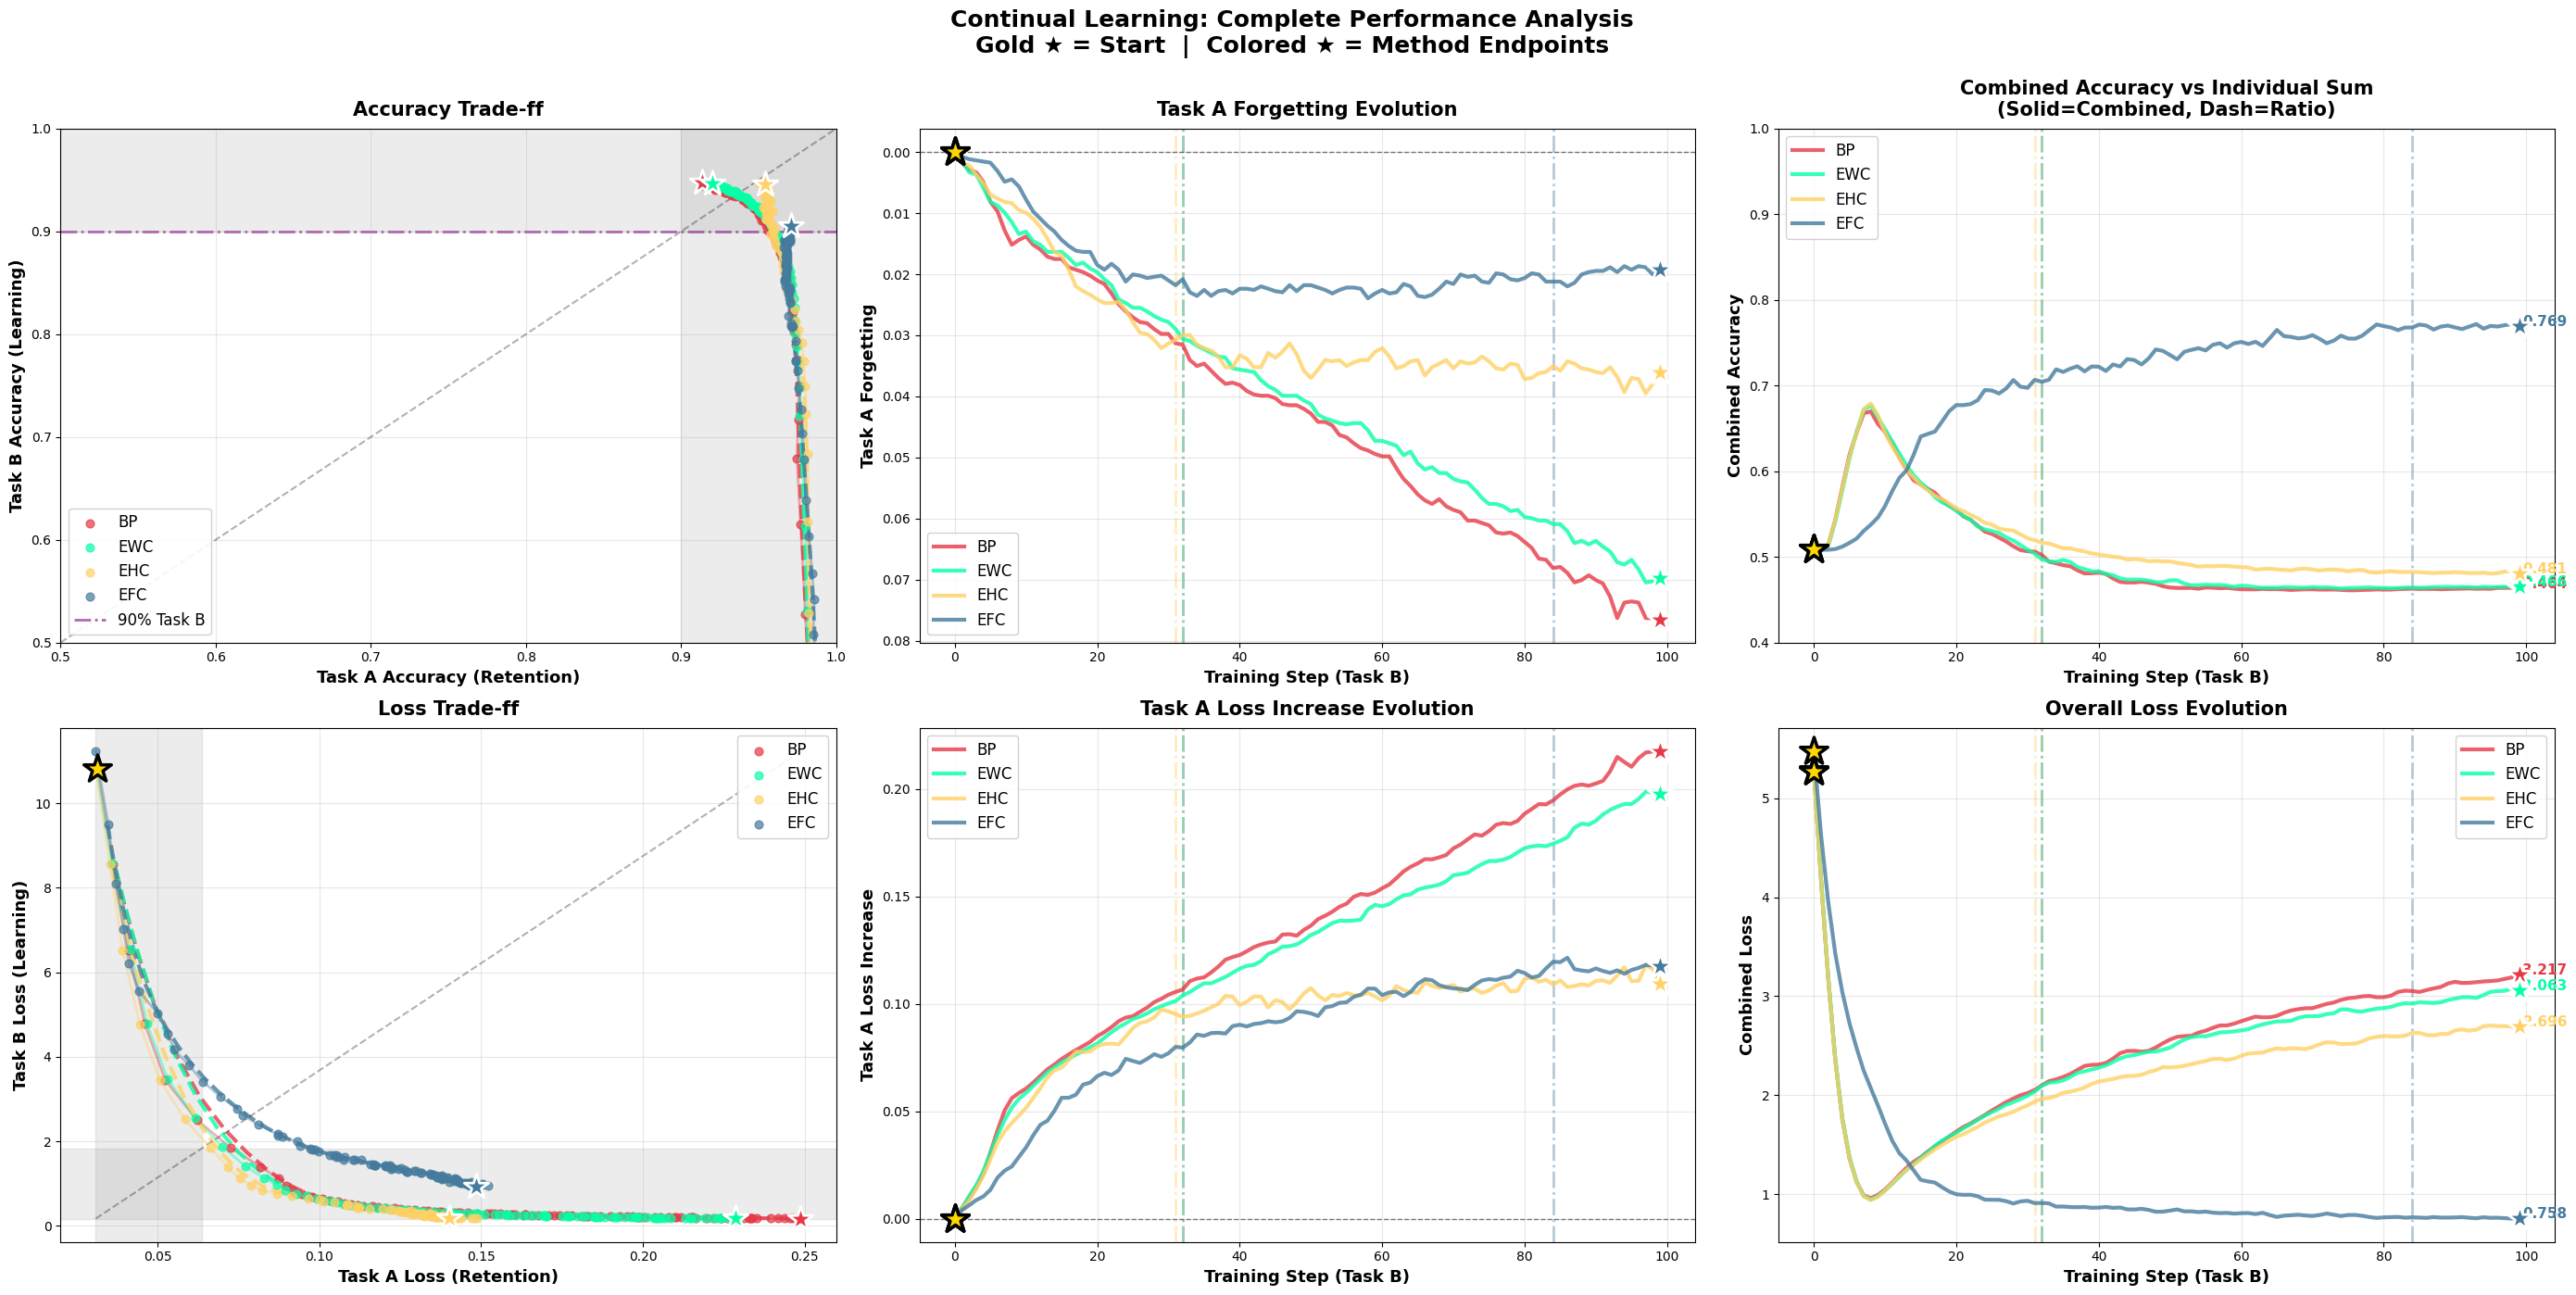


FINAL PERFORMANCE SUMMARY

BP:
  Task A Acc: 0.913 (Forgetting: 0.076)
  Combined Acc: 0.464
  Combined Loss: 3.217

EWC:
  Task A Acc: 0.920 (Forgetting: 0.070)
  Combined Acc: 0.466
  Combined Loss: 3.063

EHC:
  Task A Acc: 0.954 (Forgetting: 0.036)
  Combined Acc: 0.481
  Combined Loss: 2.696

EFC:
  Task A Acc: 0.971 (Forgetting: 0.019)
  Combined Acc: 0.769
  Combined Loss: 0.758


In [44]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d

methods = ['bp', 'ewc', 'ehc', 'efc']
end=100
# Extract data from your logs
trajectory_acc = {}
trajectory_loss = {}
for method in methods:
    trajectory_acc[method] = {
        'acc_A': acc_logs[method]['acc_A'][:end],
        'acc_B': acc_logs[method]['acc_B'][:end],
        'acc_C': acc_logs[method]['combined'][:end]
    }
    trajectory_loss[method] = {
        'loss_A': loss_logs[method]['loss_A'][:end],
        'loss_B': loss_logs[method]['loss_B'][:end],
        'loss_C': loss_logs[method]['combined'][:end]
    }

task_b_90_timepoints = {}
for method in methods:
    acc_B = np.array(trajectory_acc[method]['acc_B'])
    idx = np.where(acc_B >= 0.9)[0]
    if len(idx) > 0:
        task_b_90_timepoints[method] = idx[0]  # First timepoint where acc_B >= 0.9
    else:
        task_b_90_timepoints[method] = None

# Create figure: 2 rows (accuracy/loss) × 3 columns
fig = plt.figure(figsize=(28, 14))

# More distinct colors
colors_method = {'bp': '#E63946', 'ewc': '#06FFA5', 'ehc': '#FFD166', 'efc': '#457B9D'}  # Red, Bright cyan, Yellow, Blue

# ============ PLOT 1: Task A vs Task B Accuracy Trade-ff ============
ax1 = plt.subplot(2, 3, 1)

for method in methods:
    acc_A = np.array(trajectory_acc[method]['acc_A'])
    acc_B = np.array(trajectory_acc[method]['acc_B'])
    
    # Plot trajectory as simple line
    ax1.plot(acc_A, acc_B, '-', color=colors_method[method], 
            linewidth=2, alpha=0.4)
    
    # Scatter points (small dots)
    ax1.scatter(acc_A, acc_B, s=40, color=colors_method[method], 
               alpha=0.7, label=method.upper(), zorder=3)
    
    # Add smooth trendline
    if len(acc_A) > 3:
        acc_A_smooth = gaussian_filter1d(acc_A, sigma=2)
        acc_B_smooth = gaussian_filter1d(acc_B, sigma=2)
        ax1.plot(acc_A_smooth, acc_B_smooth, '--', color=colors_method[method], 
                linewidth=3, alpha=0.8, zorder=2)
    
    # Mark endpoint with star
    ax1.scatter(acc_A[-1], acc_B[-1], s=400, marker='*', 
               color=colors_method[method], edgecolor='white', linewidth=2, zorder=5)

# Mark common starting point
acc_A_start = trajectory_acc['bp']['acc_A'][0]
acc_B_start = trajectory_acc['bp']['acc_B'][0]
ax1.scatter(acc_A_start, acc_B_start, s=500, marker='*', 
           color='gold', edgecolor='black', linewidth=2.5, zorder=6)

# Add grey "ideal region" shading (overlapping gives darker)
ax1.axhspan(0.9, 1.0, alpha=0.15, color='grey')
ax1.axvspan(0.9, 1.0, alpha=0.15, color='grey')

# Diagonal reference line (no label)
ax1.plot([0.5, 1], [0.5, 1], 'k--', alpha=0.3, linewidth=1.5)

ax1.axhline(y=0.9, color='purple', linestyle='-.', linewidth=2, alpha=0.6, label='90% Task B', zorder=1)

ax1.set_xlabel('Task A Accuracy (Retention)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Task B Accuracy (Learning)', fontsize=13, fontweight='bold')
ax1.set_title('Accuracy Trade-ff', fontsize=15, fontweight='bold', pad=10)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=12, loc='lower left', framealpha=0.9)
ax1.set_xlim([0.5, 1.0])
ax1.set_ylim([0.5, 1.0])

# ============ PLOT 2: Task A Forgetting over Time (Accuracy) ============
ax2 = plt.subplot(2, 3, 2)

for method in methods:
    acc_A = np.array(trajectory_acc[method]['acc_A'])
    initial_acc_A = acc_A[0]
    forgetting = initial_acc_A - acc_A
    steps = np.arange(len(acc_A))
    
    # Mark starting point with star
    ax2.scatter(steps[0], forgetting[0], s=500, marker='*', 
               color='gold', edgecolor='black', linewidth=2.5, zorder=6)
    
    ax2.plot(steps, forgetting, '-', color=colors_method[method], 
            linewidth=3, markersize=5, label=method.upper(), alpha=0.8)
    
    # Mark endpoint with star
    ax2.scatter(steps[-1], forgetting[-1], s=400, marker='*', 
               color=colors_method[method], edgecolor='white', linewidth=2, zorder=5)
    
for method in methods:
    if task_b_90_timepoints[method] is not None:
        ax2.axvline(x=task_b_90_timepoints[method], color=colors_method[method], 
                   linestyle='-.', linewidth=2, alpha=0.4, zorder=1)

ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('Training Step (Task B)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Task A Forgetting', fontsize=13, fontweight='bold')
ax2.set_title('Task A Forgetting Evolution', fontsize=15, fontweight='bold', pad=10)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=12, loc='best', framealpha=0.9)
ax2.invert_yaxis()

# ============ PLOT 3: Combined Performance with Ratio Overlay ============
ax3 = plt.subplot(2, 3, 3)

for method in methods:
    acc_C = np.array(trajectory_acc[method]['acc_C'])
    acc_A = np.array(trajectory_acc[method]['acc_A'])
    acc_B = np.array(trajectory_acc[method]['acc_B'])
    steps = np.arange(len(acc_C))
    
    # Calculate ratio: combined / (acc_A + acc_B)
    ratio = acc_C / (acc_A + acc_B + 1e-10)
    
    # Mark starting point with star
    ax3.scatter(steps[0], acc_C[0], s=500, marker='*', 
               color='gold', edgecolor='black', linewidth=2.5, zorder=6)
    
    # Plot combined accuracy (solid line, left y-axis)
    ax3.plot(steps, acc_C, '-', color=colors_method[method], 
            linewidth=3, markersize=5, label=method.upper(), alpha=0.8)
    
    
    # Mark endpoint with star and value
    ax3.scatter(steps[-1], acc_C[-1], s=400, marker='*', 
               color=colors_method[method], edgecolor='white', linewidth=2, zorder=5)
    ax3.text(steps[-1]+0.5, acc_C[-1], f'{acc_C[-1]:.3f}', 
            fontsize=11, fontweight='bold', color=colors_method[method])

for method in methods:
    if task_b_90_timepoints[method] is not None:
        ax3.axvline(x=task_b_90_timepoints[method], color=colors_method[method], 
                   linestyle='-.', linewidth=2, alpha=0.4, zorder=1)


ax3.set_xlabel('Training Step (Task B)', fontsize=13, fontweight='bold')
ax3.set_ylabel('Combined Accuracy', fontsize=13, fontweight='bold', color='black')
ax3.set_title('Combined Accuracy vs Individual Sum\n(Solid=Combined, Dash=Ratio)', 
             fontsize=15, fontweight='bold', pad=10)
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=12, loc='upper left', framealpha=0.9)
ax3.set_ylim([0.4, 1.0])


# ============ PLOT 4: Task A vs Task B Loss Trade-ff ============
ax4 = plt.subplot(2, 3, 4)

for method in methods:
    loss_A = np.array(trajectory_loss[method]['loss_A'])
    loss_B = np.array(trajectory_loss[method]['loss_B'])
    
    # Plot trajectory
    ax4.plot(loss_A, loss_B, '-', color=colors_method[method], 
            linewidth=2, alpha=0.4)
    
    # Scatter points
    ax4.scatter(loss_A, loss_B, s=40, color=colors_method[method], 
               alpha=0.7, label=method.upper(), zorder=3)
    
    # Add smooth trendline
    if len(loss_A) > 3:
        loss_A_smooth = gaussian_filter1d(loss_A, sigma=2)
        loss_B_smooth = gaussian_filter1d(loss_B, sigma=2)
        ax4.plot(loss_A_smooth, loss_B_smooth, '--', color=colors_method[method], 
                linewidth=3, alpha=0.8, zorder=2)
    
    # Mark endpoint with star
    ax4.scatter(loss_A[-1], loss_B[-1], s=400, marker='*', 
               color=colors_method[method], edgecolor='white', linewidth=2, zorder=5)

# Mark common starting point
loss_A_start = trajectory_loss['bp']['loss_A'][0]
loss_B_start = trajectory_loss['bp']['loss_B'][0]
ax4.scatter(loss_A_start, loss_B_start, s=500, marker='*', 
           color='gold', edgecolor='black', linewidth=2.5, zorder=6)

# Get reasonable axis limits
all_loss_A = np.concatenate([trajectory_loss[m]['loss_A'] for m in methods])
all_loss_B = np.concatenate([trajectory_loss[m]['loss_B'] for m in methods])
loss_A_min, loss_A_max = all_loss_A.min(), all_loss_A.max()
loss_B_min, loss_B_max = all_loss_B.min(), all_loss_B.max()

# Add grey "ideal region" shading (low loss = good, bottom-left corner)
ax4.axhspan(loss_B_min, loss_B_min + 0.15*(loss_B_max-loss_B_min), alpha=0.15, color='grey')
ax4.axvspan(loss_A_min, loss_A_min + 0.15*(loss_A_max-loss_A_min), alpha=0.15, color='grey')

# Diagonal reference line
ax4.plot([loss_A_min, loss_A_max], [loss_B_min, loss_B_max], 'k--', alpha=0.3, linewidth=1.5)

ax4.set_xlabel('Task A Loss (Retention)', fontsize=13, fontweight='bold')
ax4.set_ylabel('Task B Loss (Learning)', fontsize=13, fontweight='bold')
ax4.set_title('Loss Trade-ff', fontsize=15, fontweight='bold', pad=10)
ax4.grid(True, alpha=0.3)
ax4.legend(fontsize=12, loc='upper right', framealpha=0.9)

# ============ PLOT 5: Task A Loss Increase over Time ============
ax5 = plt.subplot(2, 3, 5)

for method in methods:
    loss_A = np.array(trajectory_loss[method]['loss_A'])
    initial_loss_A = loss_A[0]
    loss_increase = loss_A - initial_loss_A  # Increase = how much loss went up
    steps = np.arange(len(loss_A))
    
    # Mark starting point with star
    ax5.scatter(steps[0], loss_increase[0], s=500, marker='*', 
               color='gold', edgecolor='black', linewidth=2.5, zorder=6)
    
    ax5.plot(steps, loss_increase, '-', color=colors_method[method], 
            linewidth=3, markersize=5, label=method.upper(), alpha=0.8)
    
    # Mark endpoint with star
    ax5.scatter(steps[-1], loss_increase[-1], s=400, marker='*', 
               color=colors_method[method], edgecolor='white', linewidth=2, zorder=5)
    
for method in methods:
    if task_b_90_timepoints[method] is not None:
        ax5.axvline(x=task_b_90_timepoints[method], color=colors_method[method], 
                   linestyle='-.', linewidth=2, alpha=0.4, zorder=1)

ax5.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax5.set_xlabel('Training Step (Task B)', fontsize=13, fontweight='bold')
ax5.set_ylabel('Task A Loss Increase', fontsize=13, fontweight='bold')
ax5.set_title('Task A Loss Increase Evolution', fontsize=15, fontweight='bold', pad=10)
ax5.grid(True, alpha=0.3)
ax5.legend(fontsize=12, loc='best', framealpha=0.9)

# ============ PLOT 6: Combined Loss over Time ============
ax6 = plt.subplot(2, 3, 6)

for method in methods:
    loss_C = np.array(trajectory_loss[method]['loss_C'])
    steps = np.arange(len(loss_C))
    
    # Mark starting point with star
    ax6.scatter(steps[0], loss_C[0], s=500, marker='*', 
               color='gold', edgecolor='black', linewidth=2.5, zorder=6)
    
    ax6.plot(steps, loss_C, '-', color=colors_method[method], 
            linewidth=3, markersize=5, label=method.upper(), alpha=0.8)
    
    # Mark endpoint with star and value
    ax6.scatter(steps[-1], loss_C[-1], s=400, marker='*', 
               color=colors_method[method], edgecolor='white', linewidth=2, zorder=5)
    ax6.text(steps[-1]+0.5, loss_C[-1], f'{loss_C[-1]:.3f}', 
            fontsize=11, fontweight='bold', color=colors_method[method])
    
# Add vertical lines when Task B reaches 90%
for method in methods:
    if task_b_90_timepoints[method] is not None:
        ax6.axvline(x=task_b_90_timepoints[method], color=colors_method[method], 
                   linestyle='-.', linewidth=2, alpha=0.4, zorder=1)

ax6.set_xlabel('Training Step (Task B)', fontsize=13, fontweight='bold')
ax6.set_ylabel('Combined Loss', fontsize=13, fontweight='bold')
ax6.set_title('Overall Loss Evolution', fontsize=15, fontweight='bold', pad=10)
ax6.grid(True, alpha=0.3)
ax6.legend(fontsize=12, loc='best', framealpha=0.9)


plt.suptitle('Continual Learning: Complete Performance Analysis\nGold ★ = Start  |  Colored ★ = Method Endpoints', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('figs/performance_analysis.svg', format='svg', bbox_inches='tight')
plt.savefig('figs/performance_analysis.eps', format='eps', bbox_inches='tight')
plt.show()

# Print summary
print("\n" + "="*70)
print("FINAL PERFORMANCE SUMMARY")
print("="*70)
for method in methods:
    acc_A_final = trajectory_acc[method]['acc_A'][-1]
    acc_A_initial = trajectory_acc[method]['acc_A'][0]
    forgetting = acc_A_initial - acc_A_final
    acc_C_final = trajectory_acc[method]['acc_C'][-1]
    loss_C_final = trajectory_loss[method]['loss_C'][-1]
    
    print(f"\n{method.upper()}:")
    print(f"  Task A Acc: {acc_A_final:.3f} (Forgetting: {forgetting:.3f})")
    print(f"  Combined Acc: {acc_C_final:.3f}")
    print(f"  Combined Loss: {loss_C_final:.3f}")

In [13]:
with open('outputs/acc_loss_1e-4&1e-1.pkl', 'wb') as f:
    pickle.dump({'acc_logs': acc_logs, 'loss_logs': loss_logs}, f)

In [15]:
with open('outputs/acc_loss_1e-4&1e-1.pkl', 'rb') as f:
    data = pickle.load(f)

acc_logs = data['acc_logs']
loss_logs = data['loss_logs']

## 2-Task and 5-Task Class-IL

In [ ]:
# ============================================================================
# Proper 2-Task Class-IL Benchmark with EFC (400-neuron hidden layers)
# ============================================================================
# Outer loop: Train on Task A, checking when >95% acc
# Inner loop: Copy weights, compute Fisher, train Task B, record max combined acc

# Update config for benchmark
benchmark_config = dotdict({**config})
benchmark_config.layers = [784, 400, 400, 10]  # Proper benchmark size
benchmark_config.epochs = 10  # Max inner loop epochs for Task B (early stopping will kick in)
benchmark_config.lr = 5e-5  # Learning rate
benchmark_config.beta_efc = 2e-1  # EFC beta

# Storage for results
benchmark_results = {
    'task_A_epoch': [],
    'task_A_acc_at_snapshot': [],
    'max_combined_acc': [],
    'task_A_acc_at_max_combined': [],
    'task_B_acc_at_max_combined': [],
    'epoch_of_max_combined': [],
    'fisher_frobenius_norm': [],
}

# Create the outer loop EFC network for Task A
efc_net_A = EFC_network(benchmark_config).to(benchmark_config.device)
efc_net_A.task_id = 0
optimizer_A = optim.Adam(efc_net_A.parameters(), lr=benchmark_config.lr)

max_outer_epochs = 20  # Safety limit
reached_95 = False

print("="*70)
print("EFC Benchmark: 2-Task Class-IL with [784, 400, 400, 10] architecture")
print("="*70)

for outer_epoch in range(max_outer_epochs):
    # ========== Outer loop: Train one epoch on Task A ==========
    efc_net_A.train()
    pbar = tqdm(total=len(train_loader_A), desc=f"Task A Epoch {outer_epoch+1}", unit="batch", leave=True)
    
    for x, y in train_loader_A:
        x, y = x.to(benchmark_config.device), y.to(benchmark_config.device)
        optimizer_A.zero_grad()
        y_hat = efc_net_A(x)
        _ = efc_net_A.calculate_loss(y_hat, y.argmax(dim=1))
        efc_net_A.backward(y)
        optimizer_A.step()
        pbar.update(1)
    pbar.close()
    
    # Evaluate Task A accuracy
    task_A_acc, _ = evaluate(efc_net_A, test_loader_A, task_id=0, task_classes=[0, 4])
    print(f"  Task A accuracy after epoch {outer_epoch+1}: {task_A_acc:.4f}")
    
    # Check if we've reached 95% (start inner loop from here)
    if task_A_acc >= 0.95:
        reached_95 = True
    
    # Only run inner loop after reaching 95%
    if not reached_95:
        continue
    
    # ========== Inner loop: Copy weights, compute Fisher, train Task B ==========
    print(f"\n  --- Running inner loop for Task A epoch {outer_epoch+1} ---")
    
    # Create fresh EFC network for Task B training
    efc_net_B = EFC_network(benchmark_config).to(benchmark_config.device)
    
    # Copy weights from Task A network
    efc_net_B.load_state_dict(deepcopy(efc_net_A.state_dict()))
    
    # Complete Task A (compute Fisher) on the copied network
    efc_net_B.task_id = 0
    efc_net_B.complete_task(train_loader_A)
    
    # Compute and print Frobenius norm of Fisher
    fisher_frob_norm = torch.sqrt(sum((f ** 2).sum() for f in efc_net_B._fisher.values())).item()
    print(f"  Fisher Frobenius norm: {fisher_frob_norm:.4f}")
    
    # Switch to Task B
    efc_net_B.task_id = 1
    efc_net_B._first_task = False
    
    # Create optimizer for Task B training
    optimizer_B = optim.Adam(efc_net_B.parameters(), lr=benchmark_config.lr)
    
    # Track best combined accuracy during Task B training
    max_combined_acc = 0.0
    best_epoch = 0
    best_acc_A = 0.0
    best_acc_B = 0.0
    no_improvement_count = 0  # Counter for early stopping
    
    # Inner loop: Train on Task B with early stopping
    for inner_epoch in range(benchmark_config.epochs):
        efc_net_B.train()
        
        pbar_inner = tqdm(total=len(train_loader_B), 
                         desc=f"    Task B Epoch {inner_epoch+1}", 
                         unit="batch", leave=False)
        
        for x, y in train_loader_B:
            x, y = x.to(benchmark_config.device), y.to(benchmark_config.device)
            optimizer_B.zero_grad()
            y_hat = efc_net_B(x)
            _ = efc_net_B.calculate_loss(y_hat, y.argmax(dim=1))
            efc_net_B.backward(y)
            optimizer_B.step()
            pbar_inner.update(1)
        pbar_inner.close()
        
        # Evaluate after each inner epoch
        acc_A, _ = evaluate(efc_net_B, test_loader_A, task_id=0, task_classes=[0, 4])
        acc_B, _ = evaluate(efc_net_B, test_loader_B, task_id=1, task_classes=[5, 9])
        combined_acc, _ = evaluate(efc_net_B, test_loader_B, task_id=1, task_classes=[0, 9])
        
        # Check for improvement
        if combined_acc > max_combined_acc:
            max_combined_acc = combined_acc
            best_epoch = inner_epoch + 1
            best_acc_A = acc_A
            best_acc_B = acc_B
            no_improvement_count = 0  # Reset counter
            marker = " *"
        else:
            no_improvement_count += 1
            marker = f" (no improvement {no_improvement_count}/2)"
        
        print(f"    Inner Epoch {inner_epoch+1:2d}: Acc = {combined_acc:.4f} (A={acc_A:.4f}, B={acc_B:.4f}){marker}")
        
        # Early stopping: stop if 2 consecutive epochs without improvement
        if no_improvement_count >= 2:
            print(f"    Early stopping triggered after {inner_epoch+1} epochs")
            break
    
    # Store results for this outer epoch
    benchmark_results['task_A_epoch'].append(outer_epoch + 1)
    benchmark_results['task_A_acc_at_snapshot'].append(task_A_acc)
    benchmark_results['max_combined_acc'].append(max_combined_acc)
    benchmark_results['task_A_acc_at_max_combined'].append(best_acc_A)
    benchmark_results['task_B_acc_at_max_combined'].append(best_acc_B)
    benchmark_results['epoch_of_max_combined'].append(best_epoch)
    benchmark_results['fisher_frobenius_norm'].append(fisher_frob_norm)
    
    print(f"  >> Best: Max Combined Acc = {max_combined_acc:.4f} "
          f"(A={best_acc_A:.4f}, B={best_acc_B:.4f}) at inner epoch {best_epoch}")
    print()

# ============================================================================
# Summary and Visualization
# ============================================================================
print("\n" + "="*70)
print("BENCHMARK RESULTS SUMMARY")
print("="*70)

for i in range(len(benchmark_results['task_A_epoch'])):
    print(f"Task A Epoch {benchmark_results['task_A_epoch'][i]:2d}: "
          f"A_init={benchmark_results['task_A_acc_at_snapshot'][i]:.3f} | "
          f"Fisher‖F‖={benchmark_results['fisher_frobenius_norm'][i]:.2f} | "
          f"Max Combined={benchmark_results['max_combined_acc'][i]:.3f} "
          f"(A={benchmark_results['task_A_acc_at_max_combined'][i]:.3f}, "
          f"B={benchmark_results['task_B_acc_at_max_combined'][i]:.3f})")

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = benchmark_results['task_A_epoch']

# Plot 1: Accuracies over Task A epochs
ax1 = axes[0]
ax1.plot(epochs, benchmark_results['task_A_acc_at_snapshot'], 'b-o', 
         label='Task A Acc (before Task B)', linewidth=2, markersize=8)
ax1.plot(epochs, benchmark_results['max_combined_acc'], 'g-s', 
         label='Max Combined Acc', linewidth=2, markersize=8)
ax1.plot(epochs, benchmark_results['task_A_acc_at_max_combined'], 'r--^', 
         label='Task A Acc (at max combined)', linewidth=2, markersize=6, alpha=0.7)
ax1.plot(epochs, benchmark_results['task_B_acc_at_max_combined'], 'm--v', 
         label='Task B Acc (at max combined)', linewidth=2, markersize=6, alpha=0.7)
ax1.set_xlabel('Task A Training Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('EFC Performance vs Task A Training Duration', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1])

# Plot 2: Fisher norm over epochs
ax2 = axes[1]
ax2.plot(epochs, benchmark_results['fisher_frobenius_norm'], 'k-o', linewidth=2, markersize=8)
ax2.set_xlabel('Task A Training Epoch', fontsize=12)
ax2.set_ylabel('Fisher Frobenius Norm', fontsize=12)
ax2.set_title('Fisher Information Growth', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Plot 3: Combined acc vs Fisher norm
ax3 = axes[2]
sc = ax3.scatter(benchmark_results['fisher_frobenius_norm'], 
                 benchmark_results['max_combined_acc'], 
                 c=epochs, cmap='viridis', s=100, edgecolors='black')
ax3.set_xlabel('Fisher Frobenius Norm', fontsize=12)
ax3.set_ylabel('Max Combined Accuracy', fontsize=12)
ax3.set_title('Combined Acc vs Fisher Magnitude', fontsize=14, fontweight='bold')
cbar = plt.colorbar(sc, ax=ax3)
cbar.set_label('Task A Epoch', fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figs/efc_benchmark_generalization.svg', format='svg', bbox_inches='tight')
plt.savefig('figs/efc_benchmark_generalization.png', format='png', dpi=150, bbox_inches='tight')
plt.show()

# Save results
with open('outputs/efc_benchmark_results.pkl', 'wb') as f:
    pickle.dump(benchmark_results, f)
print("\nResults saved to outputs/efc_benchmark_results.pkl")

Task 0: 12665 train, 2115 test
Task 1: 12089 train, 4157 test


KeyboardInterrupt: 

In [14]:
# Benchmark for 5-task Class-IL (Split-MNIST with 5 tasks, 2 classes each)

from copy import deepcopy
import pickle

# Create a copy of config for 5-task setup
benchmark_config = deepcopy(config)
benchmark_config["setting"] = "classIL5task"
benchmark_config["num_tasks"] = 5
benchmark_config["classes_per_task"] = 2
benchmark_config["epochs"] = 50  # Increase epochs since smaller tasks may need more to overtrain

# Instantiate 5-task dataloader
dataloader = ClassILMNIST5Task(benchmark_config)

# Get dataloaders for all tasks
train_loaders = []
test_loaders = []
for task_id in range(benchmark_config.num_tasks):
    train_loader, test_loader = dataloader.get_dataloaders(task_id=task_id)
    train_loaders.append(train_loader)
    test_loaders.append(test_loader)
    print(f"Task {task_id}: {len(train_loader.dataset)} train, {len(test_loader.dataset)} test")

# Full test loader for combined evaluation (assumes it contains all samples)
full_test_loader = test_loaders[-1]

# Modified evaluate function for flexibility (reuse your existing evaluate, but ensure it works for variable classes)
# Assuming your evaluate can handle arbitrary task_classes=[start_class, end_class]

# Benchmark results dictionary
benchmark_results = {
    'task_0_epoch': [],
    'task_0_acc_at_snapshot': [],
    'max_combined_acc': [],
    'task_0_acc_at_max_combined': [],
    'last_task_acc_at_max_combined': [],
    'epoch_of_max_combined': [],  # Now refers to inner epoch of the last task
    'fisher_frobenius_norm': [],  # Fisher after task 0
}

reached_95 = False
efc_net_0 = EFC_network(benchmark_config).to(benchmark_config.device)
optimizer_0 = optim.Adam(efc_net_0.parameters(), lr=benchmark_config.lr)

for outer_epoch in range(benchmark_config.epochs):
    efc_net_0.train()
    efc_net_0.task_id = 0
    
    pbar = tqdm(total=len(train_loaders[0]), 
                desc=f"Task 0 Epoch {outer_epoch+1}", 
                unit="batch", leave=True)
    
    for x, y in train_loaders[0]:
        x, y = x.to(benchmark_config.device), y.to(benchmark_config.device)
        optimizer_0.zero_grad()
        y_hat = efc_net_0(x)
        _ = efc_net_0.calculate_loss(y_hat, y.argmax(dim=1))
        efc_net_0.backward(y)
        optimizer_0.step()
        pbar.update(1)
    pbar.close()
    
    # Evaluate Task 0 accuracy
    task_0_acc, _ = evaluate(efc_net_0, test_loaders[0], task_id=0, task_classes=[0, 1])
    print(f"  Task 0 accuracy after epoch {outer_epoch+1}: {task_0_acc:.4f}")
    
    if task_0_acc >= 0.95:
        reached_95 = True
    
    if not reached_95:
        continue
    
    # ========== Inner loop: Copy weights, compute Fisher on Task 0, train Tasks 1-4 sequentially ==========
    print(f"\n  --- Running inner loop for Task 0 epoch {outer_epoch+1} ---")
    
    # Create fresh EFC network for subsequent tasks
    efc_net = EFC_network(benchmark_config).to(benchmark_config.device)
    
    # Copy weights from Task 0 network
    efc_net.load_state_dict(deepcopy(efc_net_0.state_dict()))
    
    # Complete Task 0 (compute Fisher)
    efc_net.task_id = 0
    efc_net.complete_task(train_loaders[0])
    
    # Compute and print Frobenius norm of Fisher
    fisher_frob_norm = torch.sqrt(sum((f ** 2).sum() for f in efc_net._fisher.values())).item()
    print(f"  Fisher Frobenius norm after Task 0: {fisher_frob_norm:.4f}")
    
    # Track global max combined acc across all inner training
    max_combined_acc = 0.0
    best_epoch = 0
    best_acc_0 = 0.0
    best_acc_last = 0.0
    
    # Sequentially train Tasks 1-4
    for task_id in range(1, benchmark_config.num_tasks):
        efc_net.task_id = task_id
        efc_net._first_task = False
        
        optimizer = optim.Adam(efc_net.parameters(), lr=benchmark_config.lr)
        
        no_improvement_count = 0
        task_max_combined = 0.0
        
        seen_last_class = (task_id + 1) * benchmark_config.classes_per_task - 1
        
        print(f"    Starting training on Task {task_id} (seen classes 0-{seen_last_class})")
        
        for inner_epoch in range(benchmark_config.epochs):
            efc_net.train()
            
            pbar_inner = tqdm(total=len(train_loaders[task_id]), 
                              desc=f"    Task {task_id} Epoch {inner_epoch+1}", 
                              unit="batch", leave=False)
            
            for x, y in train_loaders[task_id]:
                x, y = x.to(benchmark_config.device), y.to(benchmark_config.device)
                optimizer.zero_grad()
                y_hat = efc_net(x)
                _ = efc_net.calculate_loss(y_hat, y.argmax(dim=1))
                efc_net.backward(y)
                optimizer.step()
                pbar_inner.update(1)
            pbar_inner.close()
            
            # Evaluate combined acc on all seen classes
            combined_acc, _ = evaluate(efc_net, full_test_loader, task_id=task_id, task_classes=[0, seen_last_class])
            
            # Update global max if improved
            if combined_acc > max_combined_acc:
                max_combined_acc = combined_acc
                best_epoch = inner_epoch + 1  # Relative to this task's epochs
                best_acc_0 = evaluate(efc_net, full_test_loader, task_id=0, task_classes=[0, 1])[0]
                last_task_start = task_id * benchmark_config.classes_per_task
                last_task_end = last_task_start + benchmark_config.classes_per_task - 1
                best_acc_last = evaluate(efc_net, full_test_loader, task_id=task_id, task_classes=[last_task_start, last_task_end])[0]
            
            # Check for task-level improvement for early stopping
            if combined_acc > task_max_combined:
                task_max_combined = combined_acc
                no_improvement_count = 0
            else:
                no_improvement_count += 1
            
            marker = " *" if combined_acc == task_max_combined else f" (no improvement {no_improvement_count}/2)"
            print(f"    Inner Epoch {inner_epoch+1:2d} (Task {task_id}): Combined Acc = {combined_acc:.4f}{marker}")
            
            if no_improvement_count >= 2:
                print(f"    Early stopping for Task {task_id} after {inner_epoch+1} epochs")
                break
        
        # After training this task, compute Fisher for it to protect in next tasks
        efc_net.complete_task(train_loaders[task_id])
    
    # Store results for this outer epoch
    benchmark_results['task_0_epoch'].append(outer_epoch + 1)
    benchmark_results['task_0_acc_at_snapshot'].append(task_0_acc)
    benchmark_results['max_combined_acc'].append(max_combined_acc)
    benchmark_results['task_0_acc_at_max_combined'].append(best_acc_0)
    benchmark_results['last_task_acc_at_max_combined'].append(best_acc_last)
    benchmark_results['epoch_of_max_combined'].append(best_epoch)
    benchmark_results['fisher_frobenius_norm'].append(fisher_frob_norm)
    
    print(f"  >> Best: Max Combined Acc = {max_combined_acc:.4f} "
          f"(Task0={best_acc_0:.4f}, LastTask={best_acc_last:.4f}) at last task's epoch {best_epoch}")
    print()

# ============================================================================
# Summary and Visualization (adapted for 5-task)
# ============================================================================
print("\n" + "="*70)
print("BENCHMARK RESULTS SUMMARY (5-TASK)")
print("="*70)

for i in range(len(benchmark_results['task_0_epoch'])):
    print(f"Task 0 Epoch {benchmark_results['task_0_epoch'][i]:2d}: "
          f"0_init={benchmark_results['task_0_acc_at_snapshot'][i]:.3f} | "
          f"Fisher‖F‖={benchmark_results['fisher_frobenius_norm'][i]:.2f} | "
          f"Max Combined={benchmark_results['max_combined_acc'][i]:.3f} "
          f"(0={benchmark_results['task_0_acc_at_max_combined'][i]:.3f}, "
          f"Last={benchmark_results['last_task_acc_at_max_combined'][i]:.3f})")

# Plot similar to original (adapt labels)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = benchmark_results['task_0_epoch']

# Plot 1: Accuracies over Task 0 epochs
ax1 = axes[0]
ax1.plot(epochs, benchmark_results['task_0_acc_at_snapshot'], 'b-o', 
         label='Task 0 Acc (before others)', linewidth=2, markersize=8)
ax1.plot(epochs, benchmark_results['max_combined_acc'], 'g-s', 
         label='Max Combined Acc', linewidth=2, markersize=8)
ax1.plot(epochs, benchmark_results['task_0_acc_at_max_combined'], 'r--^', 
         label='Task 0 Acc (at max combined)', linewidth=2, markersize=6, alpha=0.7)
ax1.plot(epochs, benchmark_results['last_task_acc_at_max_combined'], 'm--v', 
         label='Last Task Acc (at max combined)', linewidth=2, markersize=6, alpha=0.7)
ax1.set_xlabel('Task 0 Training Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('EFC Performance vs Task 0 Training Duration (5-Task)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1])

# Plot 2: Fisher norm over epochs
ax2 = axes[1]
ax2.plot(epochs, benchmark_results['fisher_frobenius_norm'], 'k-o', linewidth=2, markersize=8)
ax2.set_xlabel('Task 0 Training Epoch', fontsize=12)
ax2.set_ylabel('Fisher Frobenius Norm', fontsize=12)
ax2.set_title('Fisher Information Growth after Task 0', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Plot 3: Combined acc vs Fisher norm
ax3 = axes[2]
sc = ax3.scatter(benchmark_results['fisher_frobenius_norm'], 
                 benchmark_results['max_combined_acc'], 
                 c=epochs, cmap='viridis', s=100, edgecolors='black')
ax3.set_xlabel('Fisher Frobenius Norm', fontsize=12)
ax3.set_ylabel('Max Combined Accuracy', fontsize=12)
ax3.set_title('Combined Acc vs Fisher Magnitude (5-Task)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(sc, ax=ax3)
cbar.set_label('Task 0 Epoch', fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figs/efc_benchmark_generalization_5task.svg', format='svg', bbox_inches='tight')
plt.savefig('figs/efc_benchmark_generalization_5task.png', format='png', dpi=150, bbox_inches='tight')
plt.show()

# Save results
with open('outputs/efc_benchmark_results_5task.pkl', 'wb') as f:
    pickle.dump(benchmark_results, f)
print("\nResults saved to outputs/efc_benchmark_results_5task.pkl")

Fisher:  55%|█████▌    | 66/120 [00:27<00:22,  2.41it/s]


Task 0: 12665 train, 2115 test
Task 1: 12089 train, 4157 test
Task 2: 11263 train, 6031 test
Task 3: 12183 train, 8017 test
Task 4: 11800 train, 10000 test


Task 0 Epoch 1: 100%|██████████| 50/50 [00:00<00:00, 192.76batch/s]


  Task 0 accuracy after epoch 1: 0.9972

  --- Running inner loop for Task 0 epoch 1 ---


Fisher: 100%|██████████| 50/50 [00:00<00:00, 71.26it/s]


...

    Inner Epoch  3 (Task 3): Combined Acc = 0.2828 (no improvement 2/2)
    Early stopping for Task 3 after 3 epochs


Fisher: 100%|██████████| 48/48 [00:00<00:00, 64.26it/s]


    Starting training on Task 4 (seen classes 0-9)


    Task 4 Epoch 1:  40%|████      | 19/47 [00:12<00:19,  1.46batch/s]

KeyboardInterrupt: 